# Trend & Timing

As a next step after segmentation, I look into when the business should plan promotions or staffing: seasonality, which region/category is growing fastest, and shipping delays.

## 1. Data Loading & Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sales_data = pd.read_csv('data/supermarket_sales.csv')
sales_data = sales_data.dropna()
sales_data['Order Date'] = pd.to_datetime(sales_data['Order Date'], format='%d/%m/%Y')
sales_data['Ship Date'] = pd.to_datetime(sales_data['Ship Date'], format='%d/%m/%Y')
sales_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### 1. Seasonality - sales by month-of-year

Aggregating across all years (not year+month, just month) to find the recurring seasonal pattern, independent of overall growth.

In [2]:
seasonal_sales = sales_data.groupby(sales_data['Order Date'].dt.month)['Sales'].sum()
seasonal_sales = seasonal_sales.reset_index()
seasonal_sales.columns = ['Month', 'Total Sales']

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
seasonal_sales['Month Name'] = seasonal_sales['Month'].map(month_names)
seasonal_sales

,Month,Total Sales,Month Name
0,1,91982.1396,Jan
1,2,59371.1154,Feb
2,3,197573.5872,Mar
3,4,134988.2506,Apr
4,5,154086.7237,May
5,6,145837.5233,Jun
6,7,145535.6890,Jul
7,8,157315.9270,Aug
8,9,300103.4117,Sep
9,10,199496.2947,Oct


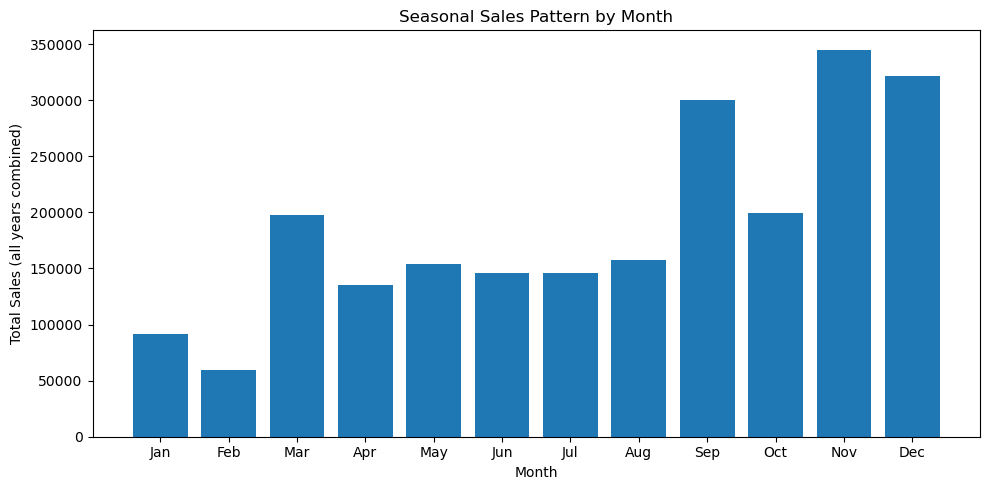

In [3]:
plt.figure(figsize=(10, 5))
plt.bar(seasonal_sales['Month Name'], seasonal_sales['Total Sales'])
plt.xlabel('Month')
plt.ylabel('Total Sales (all years combined)')
plt.title('Seasonal Sales Pattern by Month')
plt.tight_layout()
plt.show()

Sales ramp up steadily through the year and peak hard in November/December - a clear holiday-driven seasonal pattern, consistent with what the monthly regional charts in `segment_analysis.ipynb` already hinted at.

### 2. Fastest / slowest growing region and category (YoY)

In [4]:
region_yearly = sales_data.groupby(
    [sales_data['Region'], sales_data['Order Date'].dt.year.rename('Year')]
)['Sales'].sum().reset_index()

region_growth = region_yearly.copy()
region_growth['YoY Growth %'] = region_growth.groupby('Region')['Sales'].pct_change().mul(100).round(2)

# average YoY growth per region (excluding the first year, which has no prior year to compare)
avg_region_growth = region_growth.groupby('Region')['YoY Growth %'].mean().sort_values(ascending=False)
avg_region_growth

Region
West       21.363333
East       17.923333
Central    12.986667
South      10.626667
Name: YoY Growth %, dtype: float64

In [5]:
category_yearly = sales_data.groupby(
    [sales_data['Category'], sales_data['Order Date'].dt.year.rename('Year')]
)['Sales'].sum().reset_index()

category_growth = category_yearly.copy()
category_growth['YoY Growth %'] = category_growth.groupby('Category')['Sales'].pct_change().mul(100).round(2)

avg_category_growth = category_growth.groupby('Category')['YoY Growth %'].mean().sort_values(ascending=False)
avg_category_growth

Category
Office Supplies    19.150000
Technology         17.096667
Furniture          11.066667
Name: YoY Growth %, dtype: float64

Whichever region/category sits at the top of these two lists is growing fastest year over year on average; whichever sits at the bottom is growing slowest (or declining, if negative). As we saw in `overall_performance.ipynb`, an average of period-over-period growth rates can still be skewed by a single volatile year - worth checking the underlying `region_growth`/`category_growth` tables above, not just the averaged summary, before drawing conclusions.

### 3. Shipping delay analysis

In [6]:
sales_data['Shipping Delay'] = (sales_data['Ship Date'] - sales_data['Order Date']).dt.days
sales_data['Shipping Delay'].describe()

count    9789.000000
mean        3.961181
std         1.750452
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Delay, dtype: float64

In [7]:
delay_by_ship_mode = sales_data.groupby('Ship Mode')['Shipping Delay'].mean().sort_values()
delay_by_ship_mode

Ship Mode
Same Day          0.044610
First Class       2.179214
Second Class      3.249868
Standard Class    5.009916
Name: Shipping Delay, dtype: float64

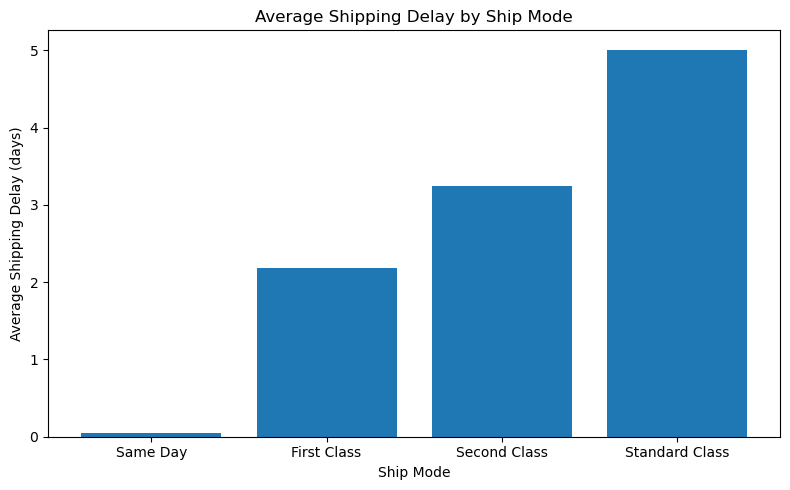

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(delay_by_ship_mode.index, delay_by_ship_mode.values)
plt.xlabel('Ship Mode')
plt.ylabel('Average Shipping Delay (days)')
plt.title('Average Shipping Delay by Ship Mode')
plt.tight_layout()
plt.show()

In [9]:
delay_by_region = sales_data.groupby('Region')['Shipping Delay'].mean().sort_values()
delay_by_region

Region
East       3.910238
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Delay, dtype: float64

Shipping delay scales roughly as expected with the Ship Mode chosen (Same Day < First Class < Second Class < Standard Class) - a sanity check that the shipping labels in this dataset behave the way they're named. Regional differences in delay are much smaller, suggesting shipping speed here is mostly a customer choice (Ship Mode), not a regional logistics issue.

## Next Steps

As a next step, I look into a simple monthly sales forecast in `forecasting.ipynb`, then package the best charts and findings into a one-page summary or dashboard.